In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import lightgbm as lgb

import joblib
import time

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
df = pd.read_csv('../data/cleaned_data.csv')

print(f"Dataset shape : {df.shape}")
print(f"Default Rate  : {df['TARGET'].mean()*100:.2f}%")

Dataset shape : (307511, 59)
Default Rate  : 8.07%


In [3]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

Features shape : (307511, 58)
Target shape   : (307511,)

Class distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64


In [4]:
# Stratified split ensures both train and test
# have the same 8% default rate proportion

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set   : {X_train.shape}")
print(f"Test set       : {X_test.shape}")
print(f"\nTrain default rate : {y_train.mean()*100:.2f}%")
print(f"Test default rate  : {y_test.mean()*100:.2f}%")

Training set   : (246008, 58)
Test set       : (61503, 58)

Train default rate : 8.07%
Test default rate  : 8.07%


In [5]:
# Calculate scale_pos_weight for XGBoost
# This tells the model to pay more attention to the minority class
# Formula: count of negative class / count of positive class

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative class (Repaid)   : {neg:,}")
print(f"Positive class (Defaulted): {pos:,}")
print(f"scale_pos_weight          : {scale_pos_weight:.2f}")
print("\nThis value will be passed to XGBoost and LightGBM")
print("It compensates for the 92/8 class imbalance")

Negative class (Repaid)   : 226,148
Positive class (Defaulted): 19,860
scale_pos_weight          : 11.39

This value will be passed to XGBoost and LightGBM
It compensates for the 92/8 class imbalance


In [6]:
# We will reuse this function for both models
# Having a reusable function is a professional practice

def evaluate_model(model_name, y_test, y_pred_proba):
    
    # Convert probabilities to binary predictions
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Metrics
    auc     = roc_auc_score(y_test, y_pred_proba)
    ap      = average_precision_score(y_test, y_pred_proba)
    
    print("=" * 50)
    print(f"  MODEL : {model_name}")
    print("=" * 50)
    print(f"  AUC-ROC Score          : {auc:.4f}")
    print(f"  Average Precision Score: {ap:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Repaid', 'Defaulted']))
    
    return auc, ap, y_pred

In [7]:
print("Training XGBoost model...")
start = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators       = 500,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = scale_pos_weight,
    use_label_encoder  = False,
    eval_metric        = 'auc',
    early_stopping_rounds = 50,
    random_state       = 42,
    n_jobs             = -1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

xgb_time = time.time() - start
print(f"\nXGBoost training time: {xgb_time:.1f} seconds")

Training XGBoost model...
[0]	validation_0-auc:0.71337
[100]	validation_0-auc:0.75167
[200]	validation_0-auc:0.75534
[284]	validation_0-auc:0.75583

XGBoost training time: 16.2 seconds


In [8]:
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc, xgb_ap, xgb_pred = evaluate_model(
    "XGBoost", y_test, xgb_proba
)

  MODEL : XGBoost
  AUC-ROC Score          : 0.7559
  Average Precision Score: 0.2421

  Classification Report:
              precision    recall  f1-score   support

      Repaid       0.96      0.72      0.82     56538
   Defaulted       0.17      0.65      0.27      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.72      0.78     61503



In [9]:
print("Training LightGBM model...")
start = time.time()

lgb_model = lgb.LGBMClassifier(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

lgb_time = time.time() - start
print(f"\nLightGBM training time: {lgb_time:.1f} seconds")

Training LightGBM model...

LightGBM training time: 5.2 seconds


In [10]:
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]
lgb_auc, lgb_ap, lgb_pred = evaluate_model(
    "LightGBM", y_test, lgb_proba
)

  MODEL : LightGBM
  AUC-ROC Score          : 0.7176
  Average Precision Score: 0.1848

  Classification Report:
              precision    recall  f1-score   support

      Repaid       0.92      1.00      0.96     56538
   Defaulted       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



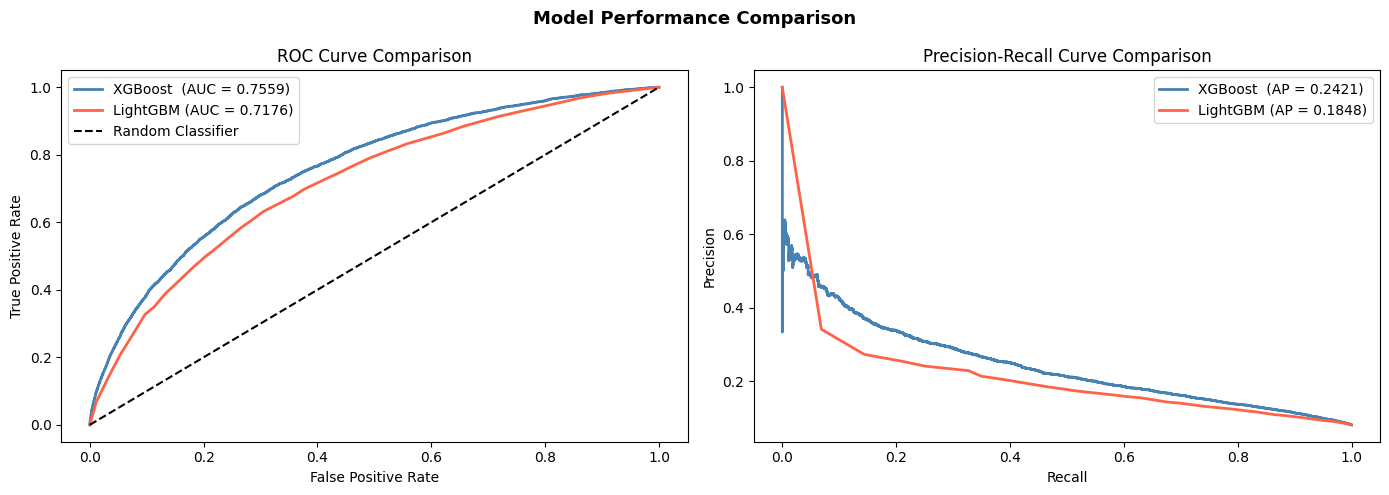

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, lgb_proba)

axes[0].plot(xgb_fpr, xgb_tpr,
             label=f'XGBoost  (AUC = {xgb_auc:.4f})',
             color='steelblue', lw=2)
axes[0].plot(lgb_fpr, lgb_tpr,
             label=f'LightGBM (AUC = {lgb_auc:.4f})',
             color='tomato', lw=2)
axes[0].plot([0,1], [0,1], 'k--', label='Random Classifier')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Precision-Recall Curve
xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, xgb_proba)
lgb_prec, lgb_rec, _ = precision_recall_curve(y_test, lgb_proba)

axes[1].plot(xgb_rec, xgb_prec,
             label=f'XGBoost  (AP = {xgb_ap:.4f})',
             color='steelblue', lw=2)
axes[1].plot(lgb_rec, lgb_prec,
             label=f'LightGBM (AP = {lgb_ap:.4f})',
             color='tomato', lw=2)
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.suptitle('Model Performance Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_comparison_curves.png')
plt.show()

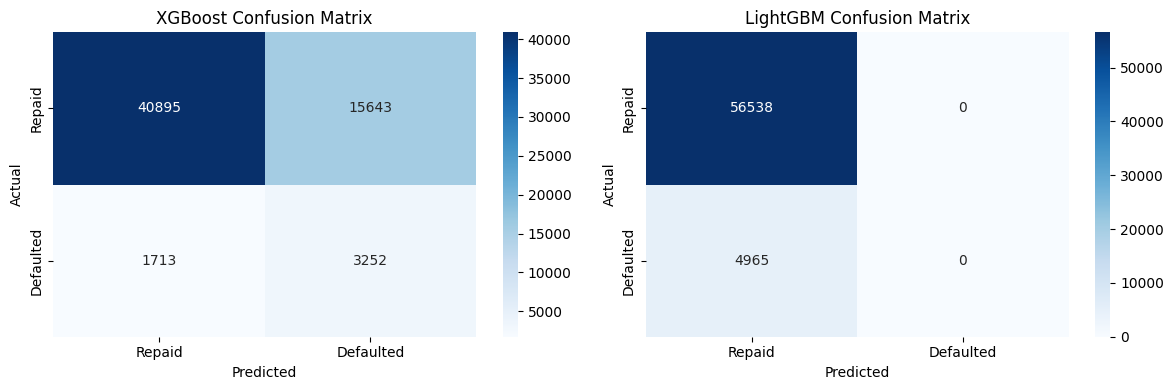

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, y_pred in zip(
    axes,
    ['XGBoost', 'LightGBM'],
    [xgb_pred, lgb_pred]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Repaid', 'Defaulted'],
                yticklabels=['Repaid', 'Defaulted'])
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../data/confusion_matrices.png')
plt.show()

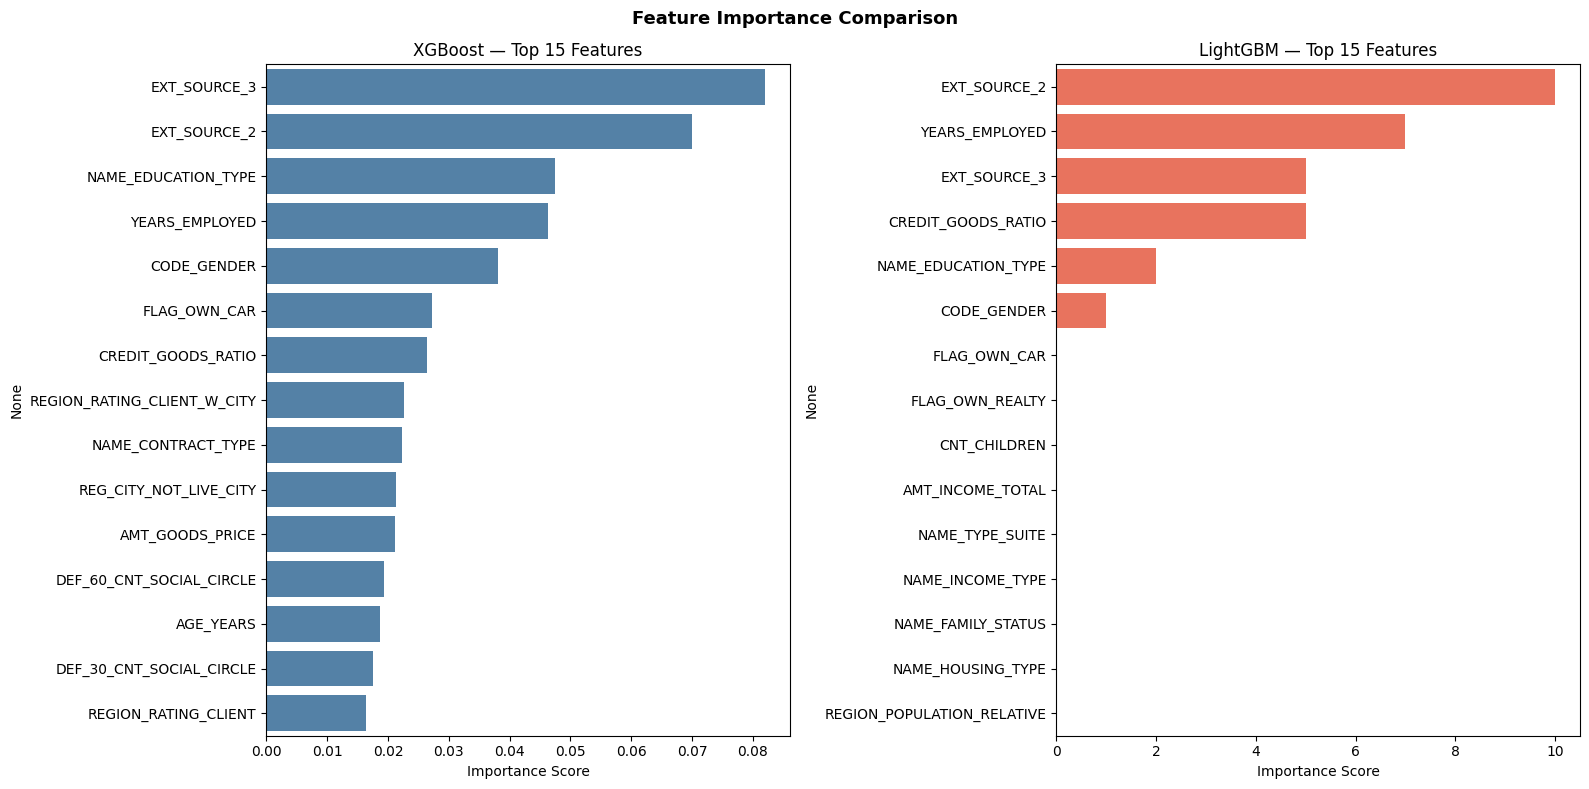

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# XGBoost feature importance
xgb_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

sns.barplot(x=xgb_imp.values,
            y=xgb_imp.index,
            color='steelblue', ax=axes[0])
axes[0].set_title('XGBoost — Top 15 Features')
axes[0].set_xlabel('Importance Score')

# LightGBM feature importance
lgb_imp = pd.Series(
    lgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

sns.barplot(x=lgb_imp.values,
            y=lgb_imp.index,
            color='tomato', ax=axes[1])
axes[1].set_title('LightGBM — Top 15 Features')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/feature_importance.png')
plt.show()

In [14]:
# 5-fold stratified cross validation
# This gives a more reliable estimate of model performance
# than a single train-test split

print("Running 5-Fold Cross Validation...")
print("(This may take a few minutes)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv_scores = cross_val_score(
    xgb.XGBClassifier(
        n_estimators     = 300,
        max_depth        = 6,
        learning_rate    = 0.05,
        scale_pos_weight = scale_pos_weight,
        eval_metric      = 'auc',
        random_state     = 42,
        n_jobs           = -1
    ),
    X_train, y_train,
    cv      = cv,
    scoring = 'roc_auc',
    n_jobs  = -1
)

lgb_cv_scores = cross_val_score(
    lgb.LGBMClassifier(
        n_estimators     = 300,
        max_depth        = 6,
        learning_rate    = 0.05,
        scale_pos_weight = scale_pos_weight,
        random_state     = 42,
        n_jobs           = -1,
        verbose          = -1
    ),
    X_train, y_train,
    cv      = cv,
    scoring = 'roc_auc',
    n_jobs  = -1
)

print("\nCross Validation Results:")
print(f"XGBoost  AUC: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")
print(f"LightGBM AUC: {lgb_cv_scores.mean():.4f} (+/- {lgb_cv_scores.std():.4f})")

Running 5-Fold Cross Validation...
(This may take a few minutes)

Cross Validation Results:
XGBoost  AUC: 0.7479 (+/- 0.0023)
LightGBM AUC: 0.7500 (+/- 0.0021)


In [15]:
print("=" * 55)
print("       FINAL MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Metric':<30} {'XGBoost':>10} {'LightGBM':>10}")
print("-" * 55)
print(f"{'AUC-ROC Score':<30} {xgb_auc:>10.4f} {lgb_auc:>10.4f}")
print(f"{'Average Precision':<30} {xgb_ap:>10.4f} {lgb_ap:>10.4f}")
print(f"{'CV AUC Mean':<30} {xgb_cv_scores.mean():>10.4f} {lgb_cv_scores.mean():>10.4f}")
print(f"{'CV AUC Std':<30} {xgb_cv_scores.std():>10.4f} {lgb_cv_scores.std():>10.4f}")
print(f"{'Training Time (sec)':<30} {xgb_time:>10.1f} {lgb_time:>10.1f}")
print("=" * 55)

# Pick best model
best_model_name = "XGBoost" if xgb_auc >= lgb_auc else "LightGBM"
best_model      = xgb_model if xgb_auc >= lgb_auc else lgb_model
best_proba      = xgb_proba if xgb_auc >= lgb_auc else lgb_proba

print(f"\nBest Model: {best_model_name} with AUC = {max(xgb_auc, lgb_auc):.4f}")

       FINAL MODEL COMPARISON SUMMARY
Metric                            XGBoost   LightGBM
-------------------------------------------------------
AUC-ROC Score                      0.7559     0.7176
Average Precision                  0.2421     0.1848
CV AUC Mean                        0.7479     0.7500
CV AUC Std                         0.0023     0.0021
Training Time (sec)                  16.2        5.2

Best Model: XGBoost with AUC = 0.7559


In [16]:
# Save both models for use in SHAP and Streamlit app
joblib.dump(xgb_model, '../models/xgb_model.pkl')
joblib.dump(lgb_model, '../models/lgb_model.pkl')

# Save test data for SHAP analysis
X_test.to_csv('../data/X_test.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

# Save feature names for Streamlit app
feature_names = X.columns.tolist()
pd.Series(feature_names).to_csv(
    '../data/feature_names.csv', index=False
)

print("Models saved to models/ folder")
print("Test data saved for Phase 5 SHAP analysis")
print("Feature names saved for Streamlit app")

Models saved to models/ folder
Test data saved for Phase 5 SHAP analysis
Feature names saved for Streamlit app
